# 01 — Data Validation and Stratified Split

Clean and validate the raw dataset, then create the reproducible train/test partitions consumed by notebook `02`.

## 1. Configuration, loading and cleaning

In [1]:
from bnpl_credit_risk.data.cleaning import BNPLDataCleaner
from bnpl_credit_risk.data.loaders import BNPLDataLoader
from bnpl_credit_risk.data.schemas import training_input_schema
from bnpl_credit_risk.data.validation import BNPLDataValidator
from bnpl_credit_risk.settings import get_settings, load_config

settings = get_settings()
config = load_config()

loader = BNPLDataLoader(settings, config.data)
cleaner = BNPLDataCleaner(config.data)
df = cleaner.clean(loader.load_raw())

print(f"Clean dataset shape: {df.shape}")

2026-08-27 17:15:08.751 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/raw/BNPL_CreditRisk_Dataset.csv rows=10345 columns=17
2026-08-27 17:15:08.761 | INFO     | bnpl_credit_risk.data.cleaning:clean:45 - Cleaned dataframe rows=10345 columns=17


Clean dataset shape: (10345, 17)


## 2. Training data contract

The training schema requires the target and validates structure, value bounds and allowed categories according to `configs/data.yaml`.

In [2]:
schema = training_input_schema(config.data)
validator = BNPLDataValidator(
    schema=schema,
    strategy=config.data.validation.strategy,
)
validation_result = validator.validate(df)
validation_result.report

2026-08-27 17:15:08.793 | INFO     | bnpl_credit_risk.data.validation:validate:122 - Validation complete strategy=strict valid_rows=10345 invalid_rows=0


{'n_valid_rows': 10345,
 'n_invalid_rows': 0,
 'structural_violations': [],
 'row_issue_counts': {}}

## 3. Stratified train/test split

The pipeline receives the cleaned DataFrame explicitly. Split proportion, random seed, output files and figure size are read from `configs/data_split.yaml`.

2026-08-27 17:15:10.385 | INFO     | bnpl_credit_risk.pipelines.data_split_pipeline:run:48 - Starting stratified data split pipeline test_size=10.0%
2026-08-27 17:15:10.404 | INFO     | bnpl_credit_risk.data.validation:validate:122 - Validation complete strategy=strict valid_rows=10345 invalid_rows=0
2026-08-27 17:15:10.421 | INFO     | bnpl_credit_risk.data.partitioning:stratified_train_test_split:76 - Stratified split complete train_rows=9310 (90.0%) test_rows=1035 (10.0%) seed=42
2026-08-27 17:15:10.423 | INFO     | bnpl_credit_risk.data.partitioning:stratified_train_test_split:84 - Target distribution train={'0': 0.6095, '1': 0.3905} test={'0': 0.6097, '1': 0.3903}
2026-08-27 17:15:10.483 | INFO     | bnpl_credit_risk.data.partitioning:save_train_test_csv:119 - Saved dataset partitions train=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/raw/train.csv test=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/raw/test.csv
2026-08-27 17:15:10.729 |

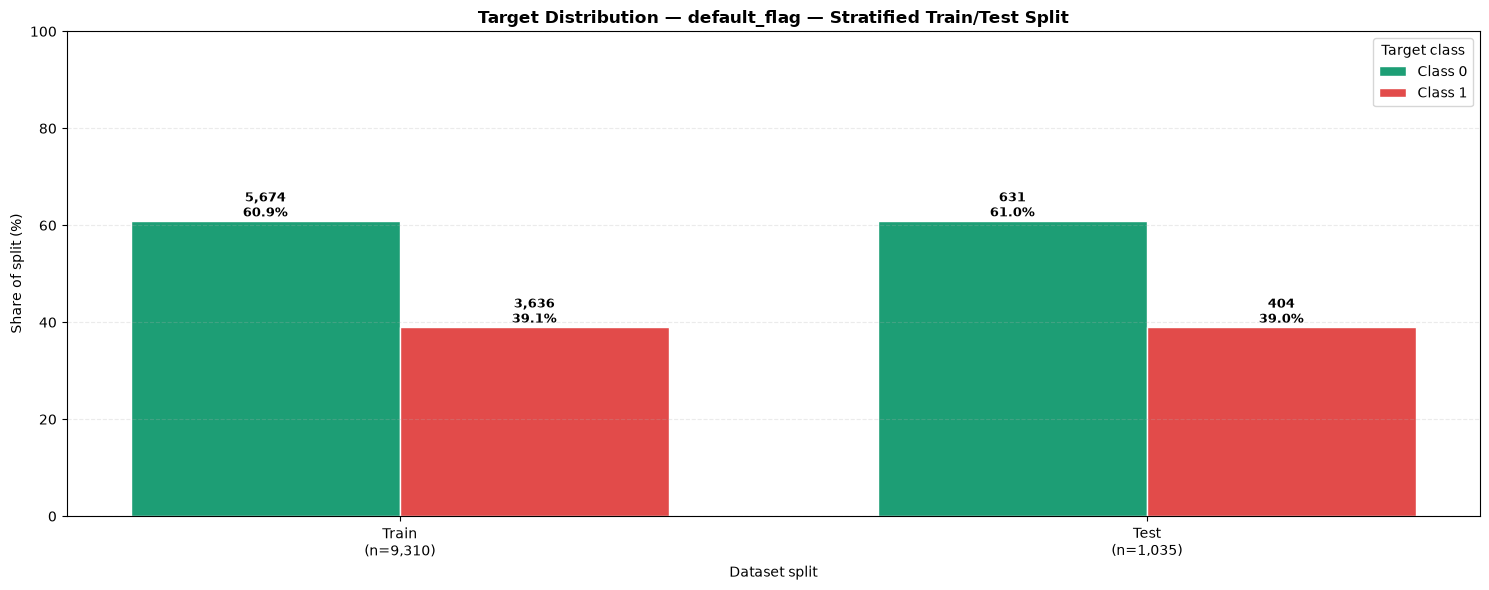

Train shape: (9310, 17)
Test shape: (1035, 17)
Train path: /Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/raw/train.csv
Test path: /Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/raw/test.csv


In [3]:
from bnpl_credit_risk.pipelines.data_split_pipeline import (
    StratifiedDataSplitPipeline,
)

split_pipeline = StratifiedDataSplitPipeline(
    settings=settings,
    config=config,
)
split_result = split_pipeline.run(df)

display(split_result.figure)
print(f"Train shape: {split_result.split.train.shape}")
print(f"Test shape: {split_result.split.test.shape}")
print(f"Train path: {split_result.paths.train_path}")
print(f"Test path: {split_result.paths.test_path}")

### Output for the next step

Notebook `02` reads the generated `train.csv` and `test.csv` files. Run this notebook completely before starting the EDA and leakage analysis.